# 01 – Exploratory Data Analysis

## Objective

This notebook focuses on:

- Importing raw natural gas consumption data
- Cleaning and transforming the dataset
- Converting units (MMcf → Bcf)
- Setting proper datetime index
- Ensuring correct monthly frequency

This notebook produces a clean, modeling-ready dataset.

In [42]:
import sys
import os
import importlib
import plotly.express as px
import seaborn as sns

# Add src folder to path
sys.path.append(os.path.abspath("../src"))
import data_loader

importlib.reload(data_loader)
from data_loader import load_ng_consumption

import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df = load_ng_consumption("../data/NaturalGasConsumption.xls")

df.head()

,U.S. Natural Gas Total Consumption (Bcf),Year,Month,Quarter
Date,,,,
2001-01-01,2676.998,2001,1,1
2001-02-01,2309.464,2001,2,1
2001-03-01,2246.633,2001,3,1
2001-04-01,1807.170,2001,4,2
2001-05-01,1522.382,2001,5,2


In [11]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

df["U.S. Natural Gas Total Consumption (Bcf)"].describe()

Shape: (276, 4)

Data Types:
U.S. Natural Gas Total Consumption (Bcf)    float64
Year                                          int32
Month                                         int32
Quarter                                       int32
dtype: object


count     276.000000
mean     2169.976790
std       486.997608
min      1368.369000
25%      1750.871000
50%      2131.415000
75%      2488.694500
max      3593.297000
Name: U.S. Natural Gas Total Consumption (Bcf), dtype: float64

In [12]:
print(df.isnull().sum())

U.S. Natural Gas Total Consumption (Bcf)    0
Year                                        0
Month                                       0
Quarter                                     0
dtype: int64


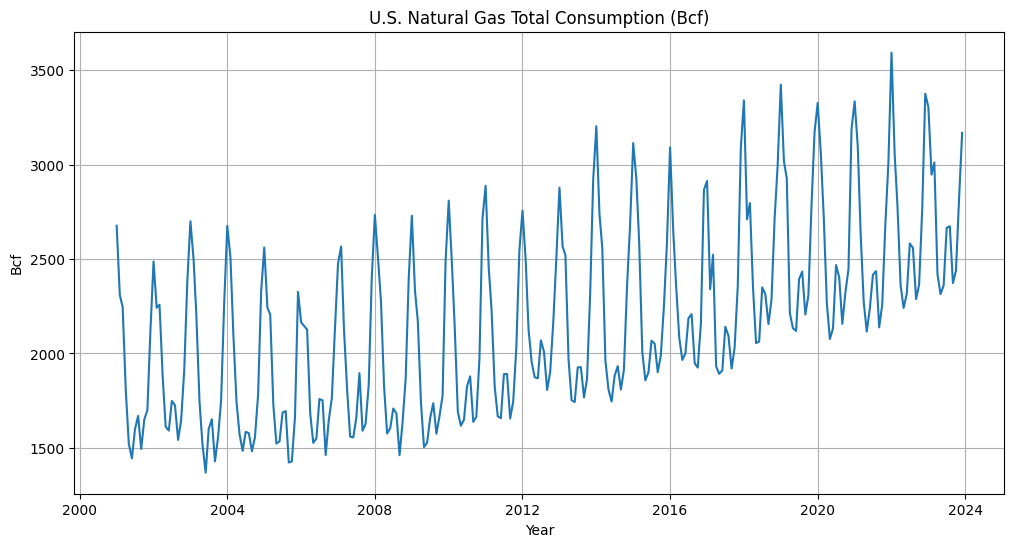

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['U.S. Natural Gas Total Consumption (Bcf)'])
plt.title("U.S. Natural Gas Total Consumption (Bcf)")
plt.xlabel("Year")
plt.ylabel("Bcf")
plt.grid()
plt.show()

In [14]:
fig = px.line(
    df,
    x=df.index,
    y="U.S. Natural Gas Total Consumption (Bcf)",
    title="Natural Gas Consumption per Year"
)
fig.show()

Yearly Trend Analysis

In [18]:
fig_yearly = px.line(
    df.groupby(['Year'])['U.S. Natural Gas Total Consumption (Bcf)'].mean().reset_index(),
    x="Year",
    y="U.S. Natural Gas Total Consumption (Bcf)",
    title="Natural Gas Consumption Trend By Year"
)
fig_yearly.show()


Monthly Seasonality Analysis

In [22]:
fig_monthly = px.bar(
    df.groupby(['Month'])['U.S. Natural Gas Total Consumption (Bcf)'].mean().reset_index(),
    x="Month",
    y="U.S. Natural Gas Total Consumption (Bcf)",
    title="Natural Gas Consumption Trend By Month"
)
fig_monthly.show()

Quarterly Analysis

In [21]:
fig_quarterly = px.bar(
    df.groupby(['Quarter'])['U.S. Natural Gas Total Consumption (Bcf)'].mean().reset_index(),
    x="Quarter",
    y="U.S. Natural Gas Total Consumption (Bcf)",
    title="Natural Gas Consumption Trend By Quarter"
)
fig_quarterly.show()

Box Plots for Variability and Seasonality

In [27]:
fig_box = px.box(df, x="Month", y="U.S. Natural Gas Total Consumption (Bcf)")
fig_box.show()

Growth Rate Analysis

In [41]:
growth_rate = df.groupby(["Year"])['U.S. Natural Gas Total Consumption (Bcf)'].mean().reset_index()
growth_rate["YoY_Growth"] = growth_rate["U.S. Natural Gas Total Consumption (Bcf)"].pct_change()*100

fig_gr = px.bar(
    growth_rate,
    x="Year",
    y="YoY_Growth",
    title="Year over Year Growth Rate of Natural Gas Consumption"
)
fig_gr.show()
